In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Load dataset
df = pd.read_csv('human_fatigue.csv')

# =========================
# 1. LIHAT DATA AWAL
# =========================
print("=== HEAD ===")
display(df.head())

# =========================
# 2. INFO DATA
# =========================
print("=== INFO ===")
df.info()

# =========================
# 3. CEK MISSING VALUE
# =========================
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# =========================
# 4. STATISTIK DATA
# =========================
print("=== DESCRIBE ===")
display(df.describe())

# =========================
# 5. CEK DATA DUPLIKAT
# =========================
print("=== DUPLICATE ===")
print(df.duplicated().sum())

=== HEAD ===


,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Time_of_Day,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score,Fatigue_Level,System_Recommendation
0,7,28,7,2.30,5.8,Evening,0,2.4,0.000,2.6,15.6,Low,Continue
1,15,77,22,3.65,4.5,Afternoon,3,1.9,0.143,4.5,97.3,High,Take Break
2,11,57,23,3.67,6.8,Night,2,2.1,0.000,4.1,55.4,Moderate,Slow Down
3,8,39,10,2.39,5.3,Afternoon,1,1.0,0.000,2.3,29.7,Low,Continue
4,7,46,16,3.05,8.2,Night,1,2.8,0.000,3.9,19.1,Low,Continue


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hours_Awake             25000 non-null  int64  
 1   Decisions_Made          25000 non-null  int64  
 2   Task_Switches           25000 non-null  int64  
 3   Avg_Decision_Time_sec   25000 non-null  float64
 4   Sleep_Hours_Last_Night  25000 non-null  float64
 5   Time_of_Day             25000 non-null  str    
 6   Caffeine_Intake_Cups    25000 non-null  int64  
 7   Stress_Level_1_10       25000 non-null  float64
 8   Error_Rate              25000 non-null  float64
 9   Cognitive_Load_Score    25000 non-null  float64
 10  Decision_Fatigue_Score  25000 non-null  float64
 11  Fatigue_Level           25000 non-null  str    
 12  System_Recommendation   25000 non-null  str    
dtypes: float64(6), int64(4), str(3)
memory usage: 3.0 MB
=== MISSING VALUES ===
Hours_Awake  

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,9.088280,45.433080,13.623480,2.918346,6.085956,1.897240,2.202736,0.031877,3.365784,40.579280
std,4.928093,25.611583,8.521595,0.942644,1.114586,1.430483,1.329868,0.057457,1.729092,36.704221
min,1.000000,0.000000,0.000000,0.500000,2.000000,0.000000,1.000000,0.000000,0.600000,0.000000
25%,5.000000,23.000000,7.000000,2.270000,5.300000,1.000000,1.000000,0.000000,1.900000,0.000000
50%,9.000000,45.000000,13.000000,2.910000,6.100000,2.000000,1.800000,0.000000,3.200000,34.650000
75%,13.000000,67.000000,20.000000,3.550000,6.900000,3.000000,3.100000,0.045000,4.600000,74.200000
max,17.000000,117.000000,48.000000,6.800000,9.000000,6.000000,8.700000,0.359000,9.700000,100.000000


=== DUPLICATE ===
1


In [41]:
# =========================
# 1. HAPUS DUPLICATE
# =========================
df = df.drop_duplicates()

print("Jumlah data setelah hapus duplicate:", df.shape)

# =========================
# 2. DROP KOLOM YANG TIDAK DIPAKAI
# =========================

# Kolom yang berpotensi data leakage
df = df.drop(columns=['System_Recommendation'])

print("Kolom setelah drop:")
print(df.columns)

Jumlah data setelah hapus duplicate: (24999, 13)
Kolom setelah drop:
Index(['Hours_Awake', 'Decisions_Made', 'Task_Switches',
       'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day',
       'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate',
       'Cognitive_Load_Score', 'Decision_Fatigue_Score', 'Fatigue_Level'],
      dtype='str')


In [42]:
print("=== df shape ===")
df.shape

=== df shape ===


(24999, 12)

In [43]:
print("=== df columns ===")
df.columns

=== df columns ===


Index(['Hours_Awake', 'Decisions_Made', 'Task_Switches',
       'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day',
       'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate',
       'Cognitive_Load_Score', 'Decision_Fatigue_Score', 'Fatigue_Level'],
      dtype='str')

In [44]:
# setting visual
sns.set(style="whitegrid")

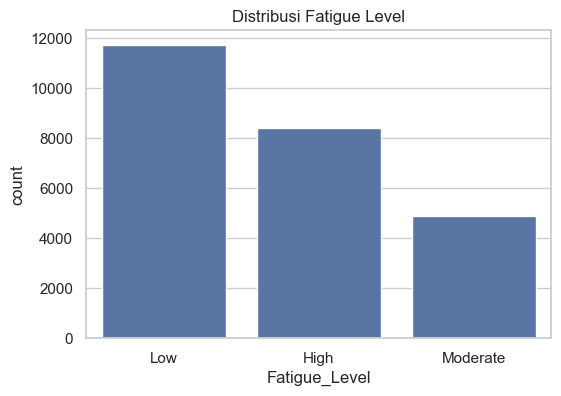

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Fatigue_Level', data=df)
plt.title('Distribusi Fatigue Level')
plt.show()

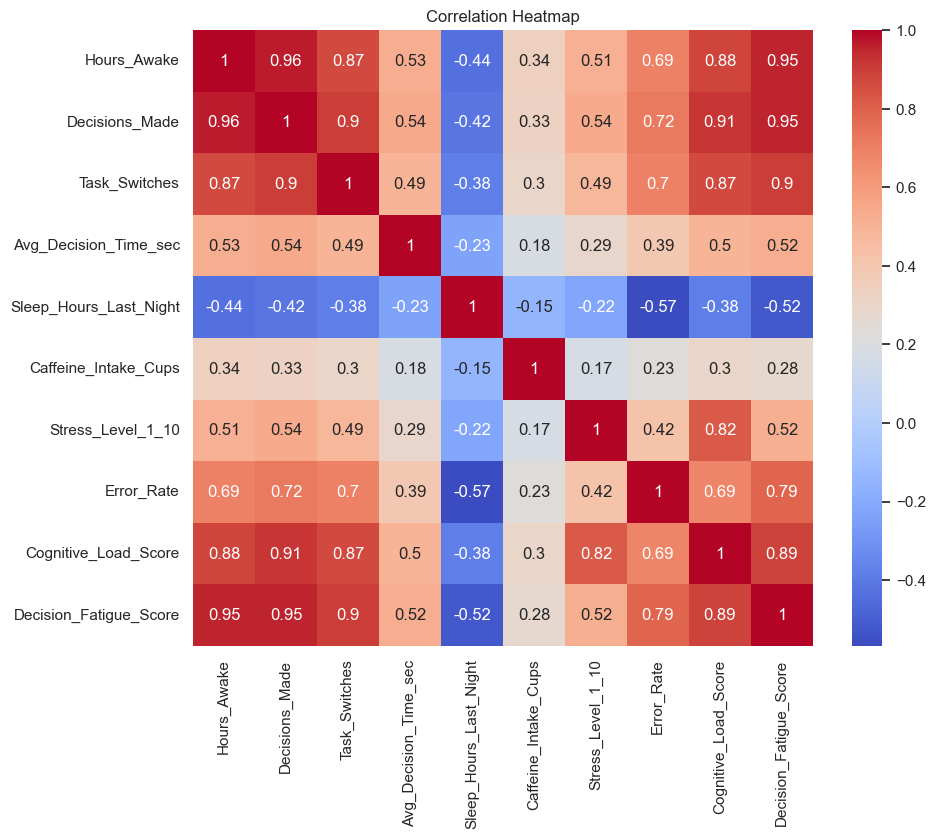

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

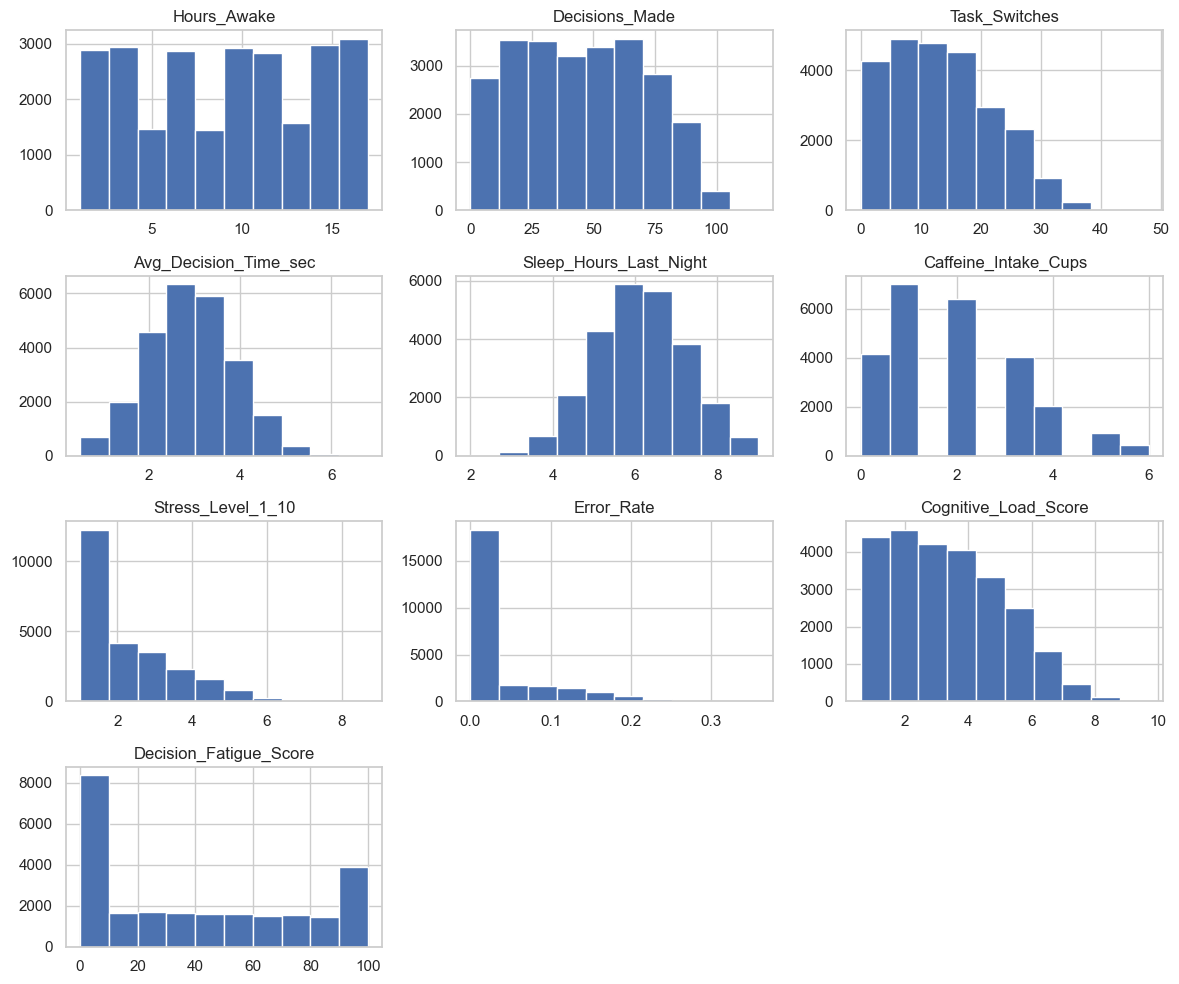

In [47]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

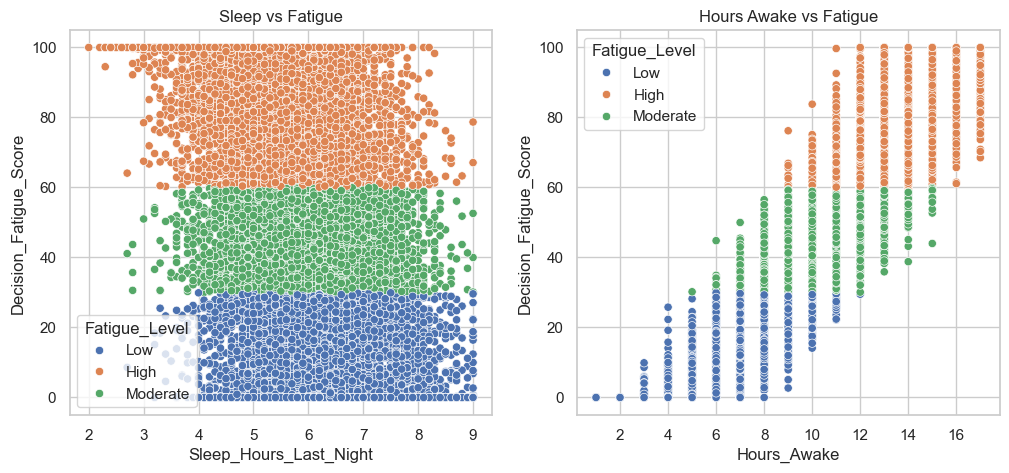

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(x='Sleep_Hours_Last_Night', y='Decision_Fatigue_Score', hue='Fatigue_Level', data=df, ax=axes[0])
axes[0].set_title('Sleep vs Fatigue')

sns.scatterplot(x='Hours_Awake', y='Decision_Fatigue_Score', hue='Fatigue_Level', data=df, ax=axes[1])
axes[1].set_title('Hours Awake vs Fatigue')

plt.show()

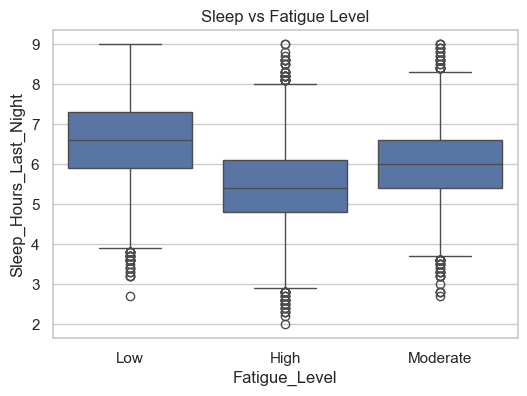

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Fatigue_Level', y='Sleep_Hours_Last_Night', data=df)
plt.title('Sleep vs Fatigue Level')
plt.show()

In [50]:
print("=== VISUALISASI DATA OPTIONAL ===")

=== VISUALISASI DATA OPTIONAL ===


<Axes: xlabel='Fatigue_Level', ylabel='Sleep_Hours_Last_Night'>

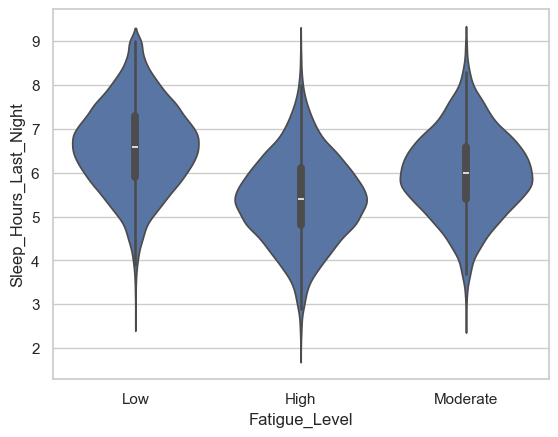

In [51]:
sns.violinplot(x='Fatigue_Level', y='Sleep_Hours_Last_Night', data=df)

In [52]:
print("=== Debug ===")

=== Debug ===


In [53]:
df.corr(numeric_only=True)

,Hours_Awake,Decisions_Made,Task_Switches,Avg_Decision_Time_sec,Sleep_Hours_Last_Night,Caffeine_Intake_Cups,Stress_Level_1_10,Error_Rate,Cognitive_Load_Score,Decision_Fatigue_Score
Hours_Awake,1.000000,0.964409,0.869039,0.528513,-0.437112,0.338442,0.512668,0.694236,0.879355,0.954371
Decisions_Made,0.964409,1.000000,0.901387,0.544786,-0.419827,0.327993,0.538229,0.718634,0.914953,0.953287
Task_Switches,0.869039,0.901387,1.000000,0.493227,-0.378195,0.296553,0.485226,0.696476,0.870986,0.899422
Avg_Decision_Time_sec,0.528513,0.544786,0.493227,1.000000,-0.232316,0.181156,0.286511,0.392622,0.495779,0.523371
Sleep_Hours_Last_Night,-0.437112,-0.419827,-0.378195,-0.232316,1.000000,-0.147453,-0.221974,-0.567523,-0.382376,-0.522242
Caffeine_Intake_Cups,0.338442,0.327993,0.296553,0.181156,-0.147453,1.000000,0.174928,0.234561,0.299596,0.277404
Stress_Level_1_10,0.512668,0.538229,0.485226,0.286511,-0.221974,0.174928,1.000000,0.421063,0.820086,0.520167
Error_Rate,0.694236,0.718634,0.696476,0.392622,-0.567523,0.234561,0.421063,1.000000,0.685356,0.787880
Cognitive_Load_Score,0.879355,0.914953,0.870986,0.495779,-0.382376,0.299596,0.820086,0.685356,1.000000,0.885435
Decision_Fatigue_Score,0.954371,0.953287,0.899422,0.523371,-0.522242,0.277404,0.520167,0.787880,0.885435,1.000000


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# =========================
# 1. ENCODING TARGET (Y)
# =========================

le = LabelEncoder()
df['Fatigue_Level'] = le.fit_transform(df['Fatigue_Level'])

print("Mapping target:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Mapping target:
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}


In [55]:
X = df.drop(['Fatigue_Level', 'Decision_Fatigue_Score'], axis=1)
y = df['Fatigue_Level']

Encoding fitur kategori

In [56]:
df['Time_of_Day'].unique()

<ArrowStringArray>
['Evening', 'Afternoon', 'Night', 'Morning']
Length: 4, dtype: str

Gunakan One Hot Encoding:

In [57]:
X = pd.get_dummies(X, columns=['Time_of_Day'], drop_first=True)

Split Data

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Cek Hasil

In [59]:
print(X_train.shape)
print(X_test.shape)

(19999, 12)
(5000, 12)


Training Model (Perbandingan ML)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

Random Forest

In [61]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.9778
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1691
           1       0.99      0.99      0.99      2343
           2       0.94      0.94      0.94       966

    accuracy                           0.98      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.98      0.98      0.98      5000



Decision Tree

In [62]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy: 0.9606
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1691
           1       0.98      0.98      0.98      2343
           2       0.90      0.90      0.90       966

    accuracy                           0.96      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.96      0.96      0.96      5000



Logistic Regression

In [63]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Accuracy: 0.9964
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1691
           1       1.00      1.00      1.00      2343
           2       1.00      0.98      0.99       966

    accuracy                           1.00      5000
   macro avg       1.00      0.99      1.00      5000
weighted avg       1.00      1.00      1.00      5000



Confusion Matrix

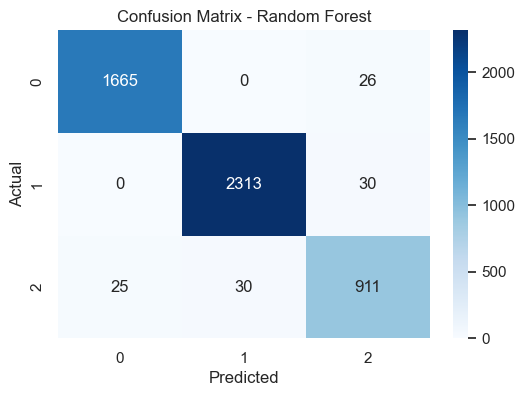

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Feature Importance (Random Forest)

In [65]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                  feature  importance
0             Hours_Awake    0.234414
1          Decisions_Made    0.232588
7              Error_Rate    0.201024
2           Task_Switches    0.128539
8    Cognitive_Load_Score    0.089014
4  Sleep_Hours_Last_Night    0.047197
3   Avg_Decision_Time_sec    0.023364
6       Stress_Level_1_10    0.022009
5    Caffeine_Intake_Cups    0.015807
9     Time_of_Day_Evening    0.002170


Logistic Regression Coefficient

In [66]:
coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print(coef.head(10))

                  feature  coefficient
0             Hours_Awake     5.708214
2           Task_Switches     1.738078
7              Error_Rate     0.834204
1          Decisions_Made     0.735772
10    Time_of_Day_Morning     0.134013
6       Stress_Level_1_10     0.070424
9     Time_of_Day_Evening    -0.013569
3   Avg_Decision_Time_sec    -0.031081
8    Cognitive_Load_Score    -0.062198
11      Time_of_Day_Night    -0.224773


## Modify Notebook

This trains and saves the model for Streamlit.

In [67]:
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

# =========================
# FEATURES & TARGET
# =========================

X = df.drop(['Fatigue_Level', 'Decision_Fatigue_Score'], axis=1)

y = df['Fatigue_Level']

# =========================
# LABEL ENCODER
# =========================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# =========================
# FEATURE TYPES
# =========================

numeric_features = [
    'Hours_Awake',
    'Decisions_Made',
    'Task_Switches',
    'Avg_Decision_Time_sec',
    'Sleep_Hours_Last_Night',
    'Caffeine_Intake_Cups',
    'Stress_Level_1_10',
    'Error_Rate',
    'Cognitive_Load_Score'
]

categorical_features = [
    'Time_of_Day'
]

# =========================
# PREPROCESSING
# =========================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# =========================
# MODEL PIPELINE
# =========================

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================
# TRAIN MODEL
# =========================

model.fit(X_train, y_train)

# =========================
# SAVE MODEL
# =========================

joblib.dump(model, 'fatigue_model.pkl')

joblib.dump(label_encoder, 'model/label_encoder.pkl')

print("Model saved successfully!")

Model saved successfully!


In [68]:
print(df.columns)

Index(['Hours_Awake', 'Decisions_Made', 'Task_Switches',
       'Avg_Decision_Time_sec', 'Sleep_Hours_Last_Night', 'Time_of_Day',
       'Caffeine_Intake_Cups', 'Stress_Level_1_10', 'Error_Rate',
       'Cognitive_Load_Score', 'Decision_Fatigue_Score', 'Fatigue_Level'],
      dtype='str')


In [69]:
print(df.Fatigue_Level)

0        1
1        0
2        2
3        1
4        1
        ..
24995    2
24996    1
24997    1
24998    1
24999    1
Name: Fatigue_Level, Length: 24999, dtype: int64


Mapping target:
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}